In [1]:
import sys
print("\n".join(sys.path))
sys.path.insert(0, "/teamspace/studios/this_studio/PINNProof/PINNProof")
print("\n".join(sys.path))

/teamspace/studios/this_studio
/teamspace/studios/this_studio/PINNProof/PINNProof/examples
/home/zeus/miniconda3/envs/cloudspace/lib/python310.zip
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/lib-dynload

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/fast_soft_sort-0.1-py3.10.egg
/teamspace/studios/this_studio/PINNProof/PINNProof
/teamspace/studios/this_studio
/teamspace/studios/this_studio/PINNProof/PINNProof/examples
/home/zeus/miniconda3/envs/cloudspace/lib/python310.zip
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/lib-dynload

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/fast_soft_sort-0.1-py3.10.egg


In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, D, P_m, X_d_dash, H, time_tensor,
                 Rs, Re, X_q_dash, Xep, Tdp, Tqp, Efd, Xd, Xq):
        super(SynchronousMachine, self).__init__()
        self.D = D
        self.P_m = P_m
        self.omega_s0 = 0.0
        self.omega_B = 2 * torch.pi * 50
        self.X_d_dash = X_d_dash
        self.H = H
        self.Rs = Rs
        self.Re = Re
        self.X_q_dash = X_q_dash
        self.Xep = Xep
        Z = torch.tensor([[self.Rs, -self.X_q_dash], [self.X_d_dash, self.Rs]])
        self.Z_inverse = torch.linalg.inv(Z)
        self.E_fd = Efd
        self.T_d_dash = Tdp
        self.T_q_dash = Tqp
        self.X_d = Xd
        self.X_q = Xq
        self.time_tensor = time_tensor
        self.V_tensor = None
        self.theta_tensor = None

    def forward(self, t, y):
        delta, omega, E_d_dash, E_q_dash,P_m, V_t,theta_vs  = y
        # V_t = self.get_V(t)
        # theta_vs = self.get_theta(t)
        v1 = E_d_dash - V_t * torch.sin(delta - theta_vs)
        v2 = E_q_dash - V_t * torch.cos(delta - theta_vs)
        I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
        I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
        P_e = E_d_dash * I_d + E_q_dash * I_q + (self.X_q_dash - self.X_d_dash) * I_d * I_q
        ddelta_dt = omega
        domega_dt = (self.omega_B / (2 * self.H)) * (P_m - P_e - self.D * omega)
        # Internal voltages assumed constant
        dE_d_dash_dt = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dE_q_dash_dt = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dP_m = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dV_t = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        d_theta_vs =torch.tensor(0.0, dtype=y.dtype, device=y.device)
        return torch.stack([ddelta_dt, domega_dt, dE_d_dash_dt, dE_q_dash_dt,dP_m, dV_t,d_theta_vs])

    def interface(self, dataset):


            Vs = dataset[:,:,-2]
            th = dataset[:,:, -1]
            delta = dataset[:,:, 0]
            omega = dataset[:,:, 1]
            E_d = dataset[:,:, 2]
            E_q = dataset[:,:, 3]

            # compute currents
            v1 = E_d - Vs * torch.sin(delta - th)
            v2 = E_q - Vs * torch.cos(delta - th)
            I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
            I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
            I_D = I_d * torch.cos(delta - torch.pi/2) - I_q * torch.sin(delta - torch.pi/2)
            I_Q = I_d * torch.sin(delta - torch.pi/2) + I_q * torch.cos(delta - torch.pi/2)
            return I_D, I_Q

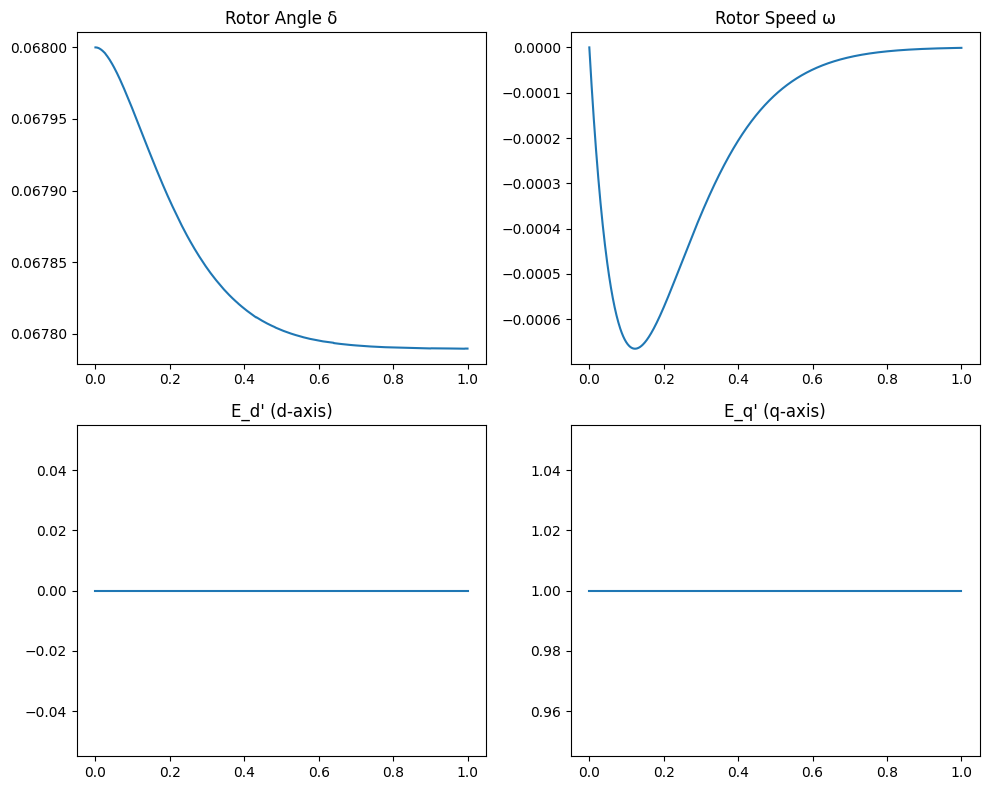

In [3]:
import torch
from torchdiffeq import odeint
from src.solvers.solver import Solver  # your base classes
from src.solvers.ODE_conventional import ODE_conventional
# from your_module import SynchronousMachine   # wherever you defined it

# 1) Create a time‐vector and a corresponding “voltage profile” for the machine.
#    Here we just hold Vs = 1.0∠0° constant.
t_final, num_points = 1.0, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs      = torch.ones(num_points)     # pu magnitude
θs      = torch.zeros(num_points)   # pu angle
V_profile = torch.stack((Vs, θs), dim=1)  # shape (num_points, 2)

# 2) Instantiate the machine with your chosen parameters.
#    SynchronousMachine.forward has signature (t, y) → dy/dt,
#    but it needs access to V_profile and t_tensor internally.
params = {
    'D': 2.364, 'P_m': 0.71, 'X_d_dash': 0.0608, 'H': 23.64,
    'Rs': 0.0, 'Re': 0.0, 'X_q_dash': 0.0969, 'Xep': 0.0,
    'Tdp': 8.96, 'Tqp': 0.31, 'Efd': 1.08, 'Xd': 0.146, 'Xq': 0.0969
}
machine = SynchronousMachine(
    params['D'], params['P_m'], params['X_d_dash'], params['H'],
    t_tensor, params['Rs'], params['Re'], params['X_q_dash'], params['Xep'],
    params['Tdp'], params['Tqp'], params['Efd'], params['Xd'], params['Xq']
)
# machine.set_time_tensor(t_tensor)
# machine.set_V_tensor(V_profile)  # (T,1,2) as your Generator4D expects

# 3) Wrap its `forward` as the ODE‐function for your solver.
#    No extra args needed since everything is on `machine` itself
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Pick an initial state [δ₀, ω₀, E′d₀, E′q₀]
x0 = [0.0680, 0.0, 0.0, 1.0,0.7, 1,0]

# 5) Solve!
t, sol = solver.solve(x0, t_final, num_points)
delta = sol[:,0]; omega = sol[:,1]
E_d = sol[:,2]; E_q = sol[:,3]

# plot all states & currents
fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()
axs[0].plot(t.squeeze(), delta.detach()); axs[0].set_title('Rotor Angle δ')
axs[1].plot(t.squeeze(), omega.detach()); axs[1].set_title('Rotor Speed ω')
axs[2].plot(t.squeeze(), E_d.detach()); axs[2].set_title("E_d' (d-axis)")
axs[3].plot(t.squeeze(), E_q.detach()); axs[3].set_title("E_q' (q-axis)")
# axs[4].plot(t.squeeze(), I_D.detach()); axs[4].set_title('Current I_D')
# axs[5].plot(t.squeeze(), I_Q.detach()); axs[5].set_title('Current I_Q')
plt.tight_layout()
# # plt.show()
# # 6) Extract and plot
# fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# axs = axs.flatten()
# labels = ['δ', 'ω', "E_d'", "E_q'", "E_q''", "E_d''", 'I_D', 'I_Q']
# for i in range(4):
#     axs[i].plot(t.squeeze(), sol[:, i].detach())
#     axs[i].set_ylabel(labels[i])
# # axs[6].plot(time_pts.squeeze(), I_D.detach()); axs[6].set_ylabel('I_D')
# # axs[7].plot(time_pts.squeeze(), I_Q.detach()); axs[7].set_ylabel('I_Q')
# for ax in axs:
#     ax.set_xlabel('Time [s]')
# plt.tight_layout()
# plt.show()


In [4]:
V_profile.shape

torch.Size([1000, 2])

In [20]:
# # ic_ranges = {
# #   'delta': (-0.1, 0.1),
# #   'omega': (-0.2, 0.2),
# #   'E_d_dash': (0.0, 0.1),
# #   'E_q_dash': (0.9, 1.1),
# #   'V_t': (0.9, 1.1),
# #   'theta_vs': (0.9, 1.1),
# # }
# ic_ranges = {
#   'delta': (-0.1, 0.1),
#   'omega': (-0.2, 0.2),
#   'E_d_dash': (0.0, 0.0),
#   'E_q_dash': (1.0,1.0),
#   'P_m': (0.7,0.7),
#   'V_t': (0.9, 1.1),
#   'theta_vs': (0.9, 1.1),
# }

# t, data, ics = solver.generate_dataset(
#     ic_ranges=ic_ranges,
#     num_ic=100,
#     t_final=t_final,
#     num_points=num_points
#     # save_path='datasets/sync_machine.npz'
# )
import torch

# 1) Your dict of ranges (in the order your state vector expects)
ic_ranges = {
  'delta':     (-0.1,  0.1),
  'omega':     (-0.2,  0.2),
  'E_d_dash':  ( 0.0,  0.0),
  'E_q_dash':  ( 1.0,  1.0),
  'P_m':       ( 0.7,  0.7),
  'V_t':       ( 0.9,  1.1),
  'theta_vs':  ( 0.9,  1.1),
}

# 2) Turn it into a (D,2) tensor in the same order
#    *Make sure this ordering matches exactly the order your solver
#     expects its initial‐condition vector y0 = [delta, omega, …, theta_vs].*
keys = ['delta','omega','E_d_dash','E_q_dash','P_m','V_t','theta_vs']
bounds = torch.tensor([ic_ranges[k] for k in keys], dtype=torch.float32)

# 3) Call generate_dataset
num_ic     = 10
t_final    = 1.0
num_points = 100

ic_tensor, traj_tensor = solver.generate_dataset(
    ic_ranges=bounds,
    num_ic=num_ic,
    t_final=t_final,
    num_points=num_points,
    sampling='random',   # or 'random'
    device='cpu',
    save_path=None       # or a path to save .pt files
)

print("Initial conditions shape:", ic_tensor.shape)       # [100, 7]
print("Trajectories shape:",      traj_tensor.shape)     # [100,1000,7]


RuntimeError: values expected sparse tensor layout but got Strided

In [5]:
#transform dataset to the right input we want it
# dataset should have the dimensions of [10,7,100]
def create_data(dataset):
    data=dataset
    x_train_list = torch.tensor(())
    y_train_list = torch.tensor(())
    for training_sample in data:
        training_sample = torch.tensor(training_sample, dtype=torch.float32)
        y_train = training_sample[1:].T.clone().detach().requires_grad_(True)
        x_train = training_sample.T
        x_train[:,1:]=x_train[0][1:]
        #discrard the first row of x_train and y_train as they are the same
        #x_train = x_train[1:]
        #y_train = y_train[1:]
        x_train = x_train.clone().detach().requires_grad_(True)
        x_train_list = torch.cat((x_train_list, x_train), 0)
        y_train_list = torch.cat((y_train_list, y_train), 0)
    return x_train_list, y_train_list

In [6]:
from pretrained_models.architectures import Network
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof")  
print("After Changing:", os.getcwd())

After Changing: /teamspace/studios/this_studio/PINNProof/PINNProof


In [7]:
model=Network(input_size=8, hidden_size=64, output_size=4, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "examples/pretrained_models/SM4_P_LBFGS_seed7.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
# 

In [19]:
# ===== generic_spec_and_utils.py =====
import os, json, math
from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint_adjoint as odeint

# -----------------------------
# Small spec describing a system
# -----------------------------
@dataclass
class DynSpec:
    D_full: int                  # dimension of full state used by machine ODE
    pred_idx: List[int]          # indices the NN predicts (size S)
    ctrl_idx: List[int]          # indices given to NN as time-varying inputs (size C)
    labels: Optional[List[str]] = None  # optional labels for all D_full states

    def __post_init__(self):
        assert len(set(self.pred_idx)) == len(self.pred_idx)
        assert len(set(self.ctrl_idx)) == len(self.ctrl_idx)
        assert self.D_full > 0
        if self.labels is not None:
            assert len(self.labels) == self.D_full

def _ensure_dir(d: str):
    os.makedirs(d, exist_ok=True)
    
def _grid(n): 
    import math
    cols = 2
    rows = math.ceil(n/cols)
    return rows, cols

# ---------------------------------------
# Dataset creation (generic, no Solver)
# ---------------------------------------
@torch.no_grad()
def generate_dataset_general(
    machine,         # nn.Module with forward(t, y)->dy/dt
    t: torch.Tensor, # (T,)
    ic_ranges: dict, # mapping name->(lo, hi), length D_full; order must match state order
    spec: DynSpec,
    num_ic: int,
    device=None
):
    """
    Returns:
      t:     (T,)
      data:  (N, D_full, T) reference/ground-truth trajectories from integrating machine.forward
      ics:   (N, D_full)
    """
    device = device or next(machine.parameters()).device if len(list(machine.parameters())) else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    t = t.to(device).float()
    T = t.numel()
    assert len(ic_ranges) == spec.D_full, "ic_ranges must have one entry per full state (ordered)."

    # Build sampling order from ic_ranges dict insertion order (Python 3.7+ preserves)
    names = list(ic_ranges.keys())
    lows  = torch.tensor([ic_ranges[k][0] for k in names], dtype=torch.float32, device=device)
    highs = torch.tensor([ic_ranges[k][1] for k in names], dtype=torch.float32, device=device)

    # Sample ICs uniformly in box
    U = torch.rand(num_ic, spec.D_full, device=device)
    ics = lows + (highs - lows) * U  # (N, D_full)

    # Integrate for each IC
    data_list = []
    for n in range(num_ic):
        y0 = ics[n]
        # odeint expects (D,), outputs (T,D); switch to (D,) dtype device
        Y = odeint(func=machine, y0=y0, t=t).to(device)  # (T, D_full)
        data_list.append(Y.T)                            # (D_full, T)
    data = torch.stack(data_list, dim=0)                 # (N, D_full, T)
    return t, data, ics

# ---------------------------------------
# Build NN inputs for one/batched rollout
# ---------------------------------------
def _build_oneshot_inputs(spec: DynSpec, t: torch.Tensor, y0_full: torch.Tensor, data_full: torch.Tensor):
    T = t.numel()
    t_in  = t.float().view(T, 1)
    y0_S  = y0_full[spec.pred_idx].float().view(1, -1).expand(T, -1)   # (T,S)
    u_t   = data_full[:, spec.ctrl_idx].float()                         # (T,C)
    x_in  = torch.cat([t_in, y0_S, u_t], dim=1)                         # (T, 1+S+C)
    return x_in, u_t

@torch.no_grad()
def oneshot_predict_full(
    model, spec: DynSpec, t: torch.Tensor, y0_full: Sequence[float], data_full: torch.Tensor, device=None
):
    """
    Returns Y_full_pred (T, D_full) where predicted indices are from NN,
    non-predicted indices are copied from data_full (useful for overlay).
    """
    device = device or next(model.parameters()).device
    t = t.to(device).float().view(-1)
    data_full = data_full.to(device).float()
    y0_full = torch.as_tensor(y0_full, dtype=torch.float32, device=device).view(-1)
    assert y0_full.numel() == spec.D_full

    x_in, _ = _build_oneshot_inputs(spec, t, y0_full, data_full)
    model.eval()
    Y_S = model(x_in)                                   # (T,S)
    Y_full = data_full.clone()
    Y_full[:, spec.pred_idx] = Y_S
    return Y_full

# --------------------------
# Residuals (one trajectory)
# --------------------------
def _dYdt_wrt_time(Y_S: torch.Tensor, t_req: torch.Tensor, create_graph=False):
    T, S = Y_S.shape
    cols = []
    for k in range(S):
        g = torch.autograd.grad(
            outputs=Y_S[:, k].sum(), inputs=t_req,
            retain_graph=True, create_graph=create_graph
        )[0]  # (T,1)
        cols.append(g)
    return torch.cat(cols, dim=1)  # (T,S)

def compute_residuals_oneshot(
    model, machine, spec: DynSpec,
    t: torch.Tensor, y0_full: Sequence[float], data_full: torch.Tensor,
    device=None, create_graph=False
):
    device = device or next(model.parameters()).device
    t = t.to(device).float().view(-1, 1)
    data_full = data_full.to(device).float()
    y0_full = torch.as_tensor(y0_full, dtype=torch.float32, device=device)

    t_req = t.detach().requires_grad_(True)            # (T,1)
    x_in, u_t = _build_oneshot_inputs(spec, t_req.view(-1), y0_full, data_full)

    model.eval()
    Y_S  = model(x_in)                                  # (T,S)
    dYdt = _dYdt_wrt_time(Y_S, t_req, create_graph=create_graph)

    # Build full Y to query machine RHS
    Y_full = data_full.clone()
    Y_full[:, spec.pred_idx] = Y_S

    f_list = []
    with torch.no_grad():
        for i in range(t_req.shape[0]):
            dy = machine.forward(t_req[i, 0], Y_full[i, :])
            f_list.append(dy)
    f_full = torch.stack(f_list, dim=0)                 # (T, D_full)
    f_pred = f_full[:, spec.pred_idx]                   # (T, S)

    residual = dYdt - f_pred
    return residual, Y_full, dYdt, f_pred

# --------------------------
# Residuals + errors (batch)
# --------------------------
def compute_batched(
    model, machine, spec: DynSpec, t: torch.Tensor, data: torch.Tensor, device=None, create_graph=False
):
    """
    data: (N, D_full, T)
    Returns:
      residual: (N, T, S)   = dY/dt - f_pred
      Y_S:      (N, T, S)   predicted subset
      dYdt:     (N, T, S)
      f_pred:   (N, T, S)
      err:      (N, T, S)   = Y_S - Y_true_S
      Y_true_S: (N, T, S)
    """
    device = device or next(model.parameters()).device
    data = data.to(device).float()
    t = t.to(device).float().view(-1)   # (T,)
    N, D, T = data.shape
    S = len(spec.pred_idx)

    # Flattened time with grad
    t_req = t.view(T, 1).expand(T, N).contiguous().clone().detach().requires_grad_(True)  # (T,N)
    t_flat = t_req.reshape(T*N, 1)

    # y0 subset (per trajectory), tiled over time
    y0_full = data[:, :, 0]                    # (N, D)
    y0_S = y0_full[:, spec.pred_idx]           # (N, S)
    y0_S_tile = y0_S.unsqueeze(0).expand(T, N, S).reshape(T*N, S)

    # controls per (T,N)
    ctrl_TNC = data[:, spec.ctrl_idx, :].permute(2, 0, 1)  # (T,N,C)
    u_flat = ctrl_TNC.reshape(T*N, -1)                     # (T*N,C)

    # NN input
    x_in = torch.cat([t_flat, y0_S_tile, u_flat], dim=1)   # (T*N, 1+S+C)

    model.eval()
    Y_S_flat = model(x_in)                                 # (T*N, S)
    Y_S = Y_S_flat.reshape(T, N, S).permute(1, 0, 2).contiguous()  # (N,T,S)

    # dY/dt
    dcols = []
    for k in range(S):
        g = torch.autograd.grad(
            outputs=Y_S_flat[:, k].sum(), inputs=t_flat,
            retain_graph=True, create_graph=create_graph
        )[0]
        dcols.append(g)
    dYdt_flat = torch.cat(dcols, dim=1)                    # (T*N, S)
    dYdt = dYdt_flat.reshape(T, N, S).permute(1, 0, 2).contiguous()

    # Build full Y to evaluate f
    Y_full = data.permute(0, 2, 1).contiguous()            # (N,T,D)
    for j, idx in enumerate(spec.pred_idx):
        Y_full[:, :, idx] = Y_S[:, :, j]

    # RHS
    f_pred = torch.empty_like(Y_S)
    with torch.no_grad():
        for n in range(N):
            rows = []
            for i in range(T):
                dy = machine.forward(t[i], Y_full[n, i, :])
                rows.append(dy[spec.pred_idx])
            f_pred[n] = torch.stack(rows, dim=0)

    # Errors vs data (reference on same indices)
    Y_true_S = data[:, spec.pred_idx, :].permute(0, 2, 1).contiguous()  # (N,T,S)
    err = Y_S - Y_true_S

    residual = dYdt - f_pred
    return residual, Y_S, dYdt, f_pred, err, Y_true_S

# --------------------------
# Metrics + CSV/plot exports
# --------------------------
def _pearsonr(a: torch.Tensor, b: torch.Tensor, eps=1e-12):
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False) + eps)
    return (a * b).mean() / denom

def export_analysis(
    t: torch.Tensor, data: torch.Tensor, ics: torch.Tensor,
    spec: DynSpec, out_dir: str,
    residual: torch.Tensor, err: torch.Tensor
):
    """
    residual: (N,T,S), err: (N,T,S)
    Saves CSVs and PNGs mirroring your previous pipeline.
    """
    _ensure_dir(out_dir)
    device = residual.device
    N, T, S = residual.shape
    labelsS = [spec.labels[idx] if spec.labels else f"s{idx}" for idx in spec.pred_idx]
    ts = t.detach().cpu().numpy().reshape(T)

    # --- CSVs ---
    import pandas as pd

    mean_abs_res_t = residual.abs().mean(dim=0).detach().cpu().numpy()  # (T,S)
    mean_abs_err_t = err.abs().mean(dim=0).detach().cpu().numpy()       # (T,S)
    rows_time = []
    for j, name in enumerate(labelsS):
        for i in range(T):
            rows_time.append({"kind":"mean_abs_residual","state":name,"t":float(ts[i]),"value":float(mean_abs_res_t[i,j])})
            rows_time.append({"kind":"mean_abs_error","state":name,"t":float(ts[i]),"value":float(mean_abs_err_t[i,j])})
    pd.DataFrame(rows_time).to_csv(os.path.join(out_dir, "time_series_mean_abs.csv"), index=False)

    res_rms_traj = torch.sqrt((residual**2).mean(dim=1)).detach().cpu().numpy()  # (N,S)
    err_rms_traj = torch.sqrt((err**2).mean(dim=1)).detach().cpu().numpy()       # (N,S)
    rows_traj = []
    for j, name in enumerate(labelsS):
        for n in range(N):
            rows_traj.append({"kind":"residual_rms","state":name,"ic_index":int(n),"value":float(res_rms_traj[n,j])})
            rows_traj.append({"kind":"error_rms","state":name,"ic_index":int(n),"value":float(err_rms_traj[n,j])})
    pd.DataFrame(rows_traj).to_csv(os.path.join(out_dir, "per_trajectory_rms.csv"), index=False)

    rmse_res = torch.sqrt((residual**2).mean(dim=(0,1))).detach().cpu().numpy()  # (S,)
    rmse_err = torch.sqrt((err**2).mean(dim=(0,1))).detach().cpu().numpy()       # (S,)
    rows_global = []
    for j, name in enumerate(labelsS):
        rows_global.append({"metric":"RMSE_residual","state":name,"value":float(rmse_res[j])})
        rows_global.append({"metric":"RMSE_error","state":name,"value":float(rmse_err[j])})
    pd.DataFrame(rows_global).to_csv(os.path.join(out_dir, "global_rmse.csv"), index=False)

    # Residual→error correlations (lags)
    lags = [0, 1, 5, 10, 20] if T > 20 else [0, 1, 5]
    res_abs = residual.abs().detach().cpu().numpy()
    err_abs = err.abs().detach().cpu().numpy()
    corr_rows = []
    for j, name in enumerate(labelsS):
        for k in lags:
            if k == 0:
                X = res_abs[:,:,j].ravel()
                Y = err_abs[:,:,j].ravel()
            else:
                X = res_abs[:,:-k,j].ravel()
                Y = err_abs[:,k:,j].ravel()
            X_t = torch.tensor(X); Y_t = torch.tensor(Y)
            corr = float(_pearsonr(X_t, Y_t))
            corr_rows.append({"state":name,"lag_steps":int(k),"pearson_r":corr})
    pd.DataFrame(corr_rows).to_csv(os.path.join(out_dir, "residual_error_correlations.csv"), index=False)

    # Best/worst ICs
    best_worst_rows = []
    ics_cpu = ics.detach().cpu().numpy()
    for j, name in enumerate(labelsS):
        res_col = res_rms_traj[:, j]
        err_col = err_rms_traj[:, j]
        i_res_best, i_res_worst = int(np.argmin(res_col)), int(np.argmax(res_col))
        i_err_best, i_err_worst = int(np.argmin(err_col)), int(np.argmax(err_col))
        for kind, idx in [("residual_best", i_res_best), ("residual_worst", i_res_worst),
                          ("error_best", i_err_best),     ("error_worst", i_err_worst)]:
            row = {"state":name, "which":kind, "ic_index":idx, "rms_value":float(res_col[idx] if 'residual' in kind else err_col[idx])}
            # dump ICs (ordered as spec)
            for d in range(spec.D_full):
                row[f"y0[{d}]"] = float(ics_cpu[idx, d])
            best_worst_rows.append(row)
    pd.DataFrame(best_worst_rows).to_csv(os.path.join(out_dir, "best_worst_ics.csv"), index=False)

    # manifest
    meta = dict(
        num_ic=int(N), num_points=int(T),
        labels_full=(spec.labels or [f"x[{i}]" for i in range(spec.D_full)]),
        pred_idx=spec.pred_idx, ctrl_idx=spec.ctrl_idx, lags=lags
    )
    with open(os.path.join(out_dir, "manifest.json"), "w") as f:
        json.dump(meta, f, indent=2)

    # --- Plots (save PNGs) ---
    def _grid(n): 
        cols=2; rows=math.ceil(n/cols); return rows, cols

    # Mean |Residual| over time
    rows, cols = _grid(S)
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows)); axs = axs.flatten()
    for j, name in enumerate(labelsS):
        axs[j].plot(ts, mean_abs_res_t[:, j]); axs[j].set_title(f"Mean |Residual| — {name}"); axs[j].grid(True)
        axs[j].set_xlabel("t [s]")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "mean_abs_residual_vs_time.png"), dpi=160); plt.close(fig)

    # Mean |Error| over time
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows)); axs = axs.flatten()
    for j, name in enumerate(labelsS):
        axs[j].plot(ts, mean_abs_err_t[:, j]); axs[j].set_title(f"Mean |Error| — {name}"); axs[j].grid(True)
        axs[j].set_xlabel("t [s]")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "mean_abs_error_vs_time.png"), dpi=160); plt.close(fig)
    # ============================================================
    # Integral-of-residual vs. Error analysis (signed, per state)
    # ============================================================
    # Shapes: residual, err ∈ (N, T, S)
    dt = torch.diff(t.view(-1)).detach().cpu()             # (T-1,)
    dt = torch.cat([dt[:1], dt], dim=0)                    # (T,) pad first step
    dt = dt.view(1, -1, 1)                                 # (1,T,1) for broadcasting

    # signed cumulative integral per trajectory/state
    int_res = torch.cumsum(residual.detach().cpu() * dt, dim=1)   # (N,T,S)

    # Convenience copies on CPU/NumPy
    err_np     = err.detach().cpu().numpy()                 # (N,T,S)
    intres_np  = int_res.numpy()                            # (N,T,S)
    ts         = t.detach().cpu().numpy().reshape(-1)       # (T,)

    # === CSV with summary curves over time (means) ===
    # mean signed values and their difference
    mean_err_t    = err.mean(dim=0).detach().cpu().numpy()        # (T,S)
    mean_int_t    = int_res.mean(dim=0).numpy()                    # (T,S)
    mean_diff_t   = (err - int_res.to(err.device)).mean(dim=0).detach().cpu().numpy()  # (T,S)

    import pandas as pd
    rows_int = []
    for j, name in enumerate(labelsS):
        for i, tt in enumerate(ts):
            rows_int.append({"state": name, "t": float(tt),
                             "mean_signed_error": float(mean_err_t[i, j]),
                             "mean_signed_intres": float(mean_int_t[i, j]),
                             "mean_signed_diff":   float(mean_diff_t[i, j])})
    pd.DataFrame(rows_int).to_csv(os.path.join(out_dir, "integral_vs_error_time_series.csv"), index=False)

    # === Per-IC metrics at final time and fitted relation over all (t) ===
    # For each state, fit err ≈ a * (∫res) + b using least squares; report a, b, R^2
    metrics_rows = []
    Tm1 = err.shape[1] - 1
    for j, name in enumerate(labelsS):
        e_all   = err_np[:, :, j].reshape(-1)        # (N*T,)
        rint_all= intres_np[:, :, j].reshape(-1)     # (N*T,)

        # LS fit: [rint, 1] theta = e
        X = np.stack([rint_all, np.ones_like(rint_all)], axis=1)   # (N*T,2)
        theta, *_ = np.linalg.lstsq(X, e_all, rcond=None)          # a, b
        a, b = float(theta[0]), float(theta[1])

        # R^2
        yhat = X @ theta
        ss_res = float(np.sum((e_all - yhat)**2))
        ss_tot = float(np.sum((e_all - np.mean(e_all))**2)) + 1e-12
        R2 = 1.0 - ss_res/ss_tot

        # At final time: scatter metrics
        e_T   = err_np[:, Tm1, j]
        r_T   = intres_np[:, Tm1, j]
        # slope & bias at final time (1D LS)
        X_T = np.stack([r_T, np.ones_like(r_T)], axis=1)
        theta_T, *_ = np.linalg.lstsq(X_T, e_T, rcond=None)
        a_T, b_T = float(theta_T[0]), float(theta_T[1])

        metrics_rows.append({
            "state": name,
            "slope_all": a, "bias_all": b, "R2_all": R2,
            "slope_T": a_T, "bias_T": b_T,
            "corr_T": float(np.corrcoef(r_T, e_T)[0,1])
        })

    pd.DataFrame(metrics_rows).to_csv(os.path.join(out_dir, "integral_vs_error_metrics.csv"), index=False)

    # === Plots ===
    rows, cols = _grid(S)

    # (A) mean curves: signed error vs signed integral of residual
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows), squeeze=False)
    axs = axs.ravel()
    for j, name in enumerate(labelsS):
        axs[j].plot(ts, mean_err_t[:, j], label="mean error (signed)")
        axs[j].plot(ts, mean_int_t[:, j], label="mean ∫ residual dt (signed)", linestyle="--")
        axs[j].set_title(f"Error vs ∫Residual — {name}")
        axs[j].set_xlabel("t [s]"); axs[j].grid(True)
    axs[0].legend(loc="best")
    for k in range(S, len(axs)): axs[k].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "integral_vs_error_mean_curves.png"), dpi=160)
    plt.close(fig)

    # (B) mean signed difference vs time
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows), squeeze=False)
    axs = axs.ravel()
    for j, name in enumerate(labelsS):
        axs[j].plot(ts, mean_diff_t[:, j])
        axs[j].set_title(f"Mean(error − ∫res) — {name}")
        axs[j].set_xlabel("t [s]"); axs[j].grid(True)
    for k in range(S, len(axs)): axs[k].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "integral_vs_error_mean_diff.png"), dpi=160)
    plt.close(fig)

    # (C) final-time scatter across ICs with y=x line
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows), squeeze=False)
    axs = axs.ravel()
    for j, name in enumerate(labelsS):
        e_T  = err_np[:, Tm1, j]
        r_T  = intres_np[:, Tm1, j]
        axs[j].scatter(r_T, e_T, s=15, alpha=0.6)
        lim = np.max(np.abs(np.concatenate([e_T, r_T]))) * 1.05 + 1e-6
        axs[j].plot([-lim, lim], [-lim, lim], 'k--', linewidth=1)
        axs[j].set_xlim([-lim, lim]); axs[j].set_ylim([-lim, lim])
        axs[j].set_xlabel("∫ residual dt (final)"); axs[j].set_ylabel("error (final)")
        axs[j].set_title(f"Final-time: error vs ∫res — {name}")
        axs[j].grid(True)
    for k in range(S, len(axs)): axs[k].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "integral_vs_error_scatter_final.png"), dpi=160)
    plt.close(fig)

    # Heatmaps of per-IC RMS residual + error
    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(res_rms_traj, aspect='auto', origin='lower')
    ax.set_xticks(range(S)); ax.set_xticklabels(labelsS, rotation=0)
    ax.set_xlabel("State"); ax.set_ylabel("IC index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="RMS residual")
    ax.set_title("Per-IC RMS residuals")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "heatmap_residual_rms.png"), dpi=160); plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(err_rms_traj, aspect='auto', origin='lower')
    ax.set_xticks(range(S)); ax.set_xticklabels(labelsS, rotation=0)
    ax.set_xlabel("State"); ax.set_ylabel("IC index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="RMS error")
    ax.set_title("Per-IC RMS errors")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "heatmap_error_rms.png"), dpi=160); plt.close(fig)

    # IC-space scatter colored by RMS error (choose two axes from full state)
    x_idx = 0
    y_idx = spec.D_full - 1
    x0 = ics[:, x_idx].detach().cpu().numpy()
    y0 = ics[:, y_idx].detach().cpu().numpy()
    fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows)); axs = axs.flatten()
    for j, name in enumerate(labelsS):
        sc = axs[j].scatter(x0, y0, c=err_rms_traj[:, j], s=30)
        axs[j].set_title(f"IC plane colored by error — {name}")
        axs[j].set_xlabel((spec.labels or [f"x[{i}]"])[x_idx])
        axs[j].set_ylabel((spec.labels or [f"x[{i}]"])[y_idx])
        axs[j].grid(True)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    mappable = plt.cm.ScalarMappable()
    mappable.set_array(err_rms_traj.ravel())
    fig.colorbar(mappable, cax=cbar_ax, label="RMS error")
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(os.path.join(out_dir, "ic_scatter_error.png"), dpi=160)
    plt.close(fig)


In [20]:
# ===== run_general_analysis.py =====
import torch
# from generic_spec_and_utils import (
#     DynSpec, generate_dataset_general, compute_batched, export_analysis
# )

def run_full_analysis_general(
    model, machine, spec: DynSpec,
    ic_ranges: dict,
    t_final: float, num_points: int, num_ic: int,
    out_dir: str = "pinn_analysis_general",
    device=None
):
    device = device or next(model.parameters()).device
    t = torch.linspace(0., t_final, num_points).to(device)

    # === Dataset ===
    t, data, ics = generate_dataset_general(machine, t, ic_ranges, spec, num_ic=num_ic, device=device)
    # data: (N, D_full, T)

    # === Residuals + Errors (batched) ===
    residual, Y_S, dYdt, f_pred, err, Y_true_S = compute_batched(
        model, machine, spec, t, data, device=device, create_graph=False
    )

    # === Exports (CSVs + PNG plots) ===
    export_analysis(t, data, ics, spec, out_dir, residual, err)

    # Return a quick summary too
    rmse_res = torch.sqrt((residual**2).mean(dim=(0,1)))
    rmse_err = torch.sqrt((err**2).mean(dim=(0,1)))
    return {
        "out_dir": out_dir,
        "RMSE_residual_per_state": { (spec.labels or [f"x[{i}]" for i in range(spec.D_full)])[k]: float(rmse_res[k]) for k in range(len(spec.pred_idx)) },
        "RMSE_error_per_state": { (spec.labels or [f"x[{i}]" for i in range(spec.D_full)])[k]: float(rmse_err[k]) for k in range(len(spec.pred_idx)) }
    }


In [21]:
# ===== example_driver.py =====
import torch
from pretrained_models.architectures import Network
# from your_module_defining_machine import SynchronousMachine  # your class from the message
# from generic_spec_and_utils import DynSpec
# from run_general_analysis import run_full_analysis_general

# --- Model (set output_size=4 for δ, ω, E′d, E′q)
model = Network(input_size=1 + 4 + 3, hidden_size=64, output_size=4, num_layers=3, activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Machine (your params/time vector not required here for the class)
params = {
    'D': 2.364, 'P_m': 0.71, 'X_d_dash': 0.0608, 'H': 23.64,
    'Rs': 0.0, 'Re': 0.0, 'X_q_dash': 0.0969, 'Xep': 0.0,
    'Tdp': 8.96, 'Tqp': 0.31, 'Efd': 1.08, 'Xd': 0.146, 'Xq': 0.0969
}
# time_tensor here is only stored; integration uses external t
t_dummy = torch.linspace(0., 1.0, 10)
machine = SynchronousMachine(
    params['D'], params['P_m'], params['X_d_dash'], params['H'],
    t_dummy, params['Rs'], params['Re'], params['X_q_dash'], params['Xep'],
    params['Tdp'], params['Tqp'], params['Efd'], params['Xd'], params['Xq']
).to(device)

# --- Spec for your system
labels7 = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$P_m$", r"$V_t$", r"$\theta_{vs}$"]
spec = DynSpec(
    D_full=7,
    pred_idx=[0,1,2,3],      # NN predicts δ, ω, E′d, E′q
    ctrl_idx=[4,5,6],        # NN sees P_m, V_t, θ_vs as time inputs
    labels=labels7
)

# --- IC ranges (order must match state order)
ic_ranges = {
    "delta":    (-0.1, 0.1),
    "omega":    (-0.6, 0.6),
    "E_d_dash": (0.0, 0.0),
    "E_q_dash": (1.0, 1.0),
    "P_m":      (params['P_m'], params['P_m']),
    "V_t":      (0.98, 1.02),
    "theta_vs": (-0.1, 0.1)
}

# --- Run full analysis (creates CSVs + PNGs)
summary = run_full_analysis_general(
    model=model,
    machine=machine,
    spec=spec,
    ic_ranges=ic_ranges,
    t_final=0.2,
    num_points=1000,
    num_ic=200,             # set to 1000 like your previous runs if you want
    out_dir="pinn_analysis_general",
    device=device
)
print(summary)


/tmp/ipykernel_17163/1550077075.py:495: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


{'out_dir': 'pinn_analysis_general', 'RMSE_residual_per_state': {'$\\delta$': 0.04933735728263855, '$\\omega$': 2.6119351387023926, "$E'_d$": 0.027220161631703377, "$E'_q$": 0.035820476710796356}, 'RMSE_error_per_state': {'$\\delta$': 0.048093266785144806, '$\\omega$': 0.30818676948547363, "$E'_d$": 0.05520768091082573, "$E'_q$": 0.9233424067497253}}
